## Getting Started
Importing libraries

In [25]:
# No DS without pd
import pandas as pd

# Import Matplotlib library and assigns shorthand 'plt'
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates # Easier to build graphs with dates with the help of mdates
# Imports Seaborn library and assigns shorthand 'sns'
import seaborn as sns
# Imports Plotly library and assigns shorthand 'px'
import plotly.express as px
# Imports Numpy library and assigns shorthand 'np'
import numpy as np

######## Shit below doesn't work########
# SQLite to not have to use a whole SQL Workbench but just runs out of a class, easier to code with
import sqlite3
# SQLite doesn't like mySQL format so I need to parse it
import pymysql
# pandassql lets you execute commands like in mySQL and is able to read stuff into an mySQL DB and converts it directly into a pd df
from pandasql import sqldf

## 1. Business Understanding
### Objective
The goal of this project is to understand and forecast product demand of a mexican toy store across different stores based on the internal company dataset.  
The dataset includes sales transactions, store information, inventory records, product details, and a calendar that helps align daily sales with time-based patterns such as holidays or promotions.

### Business Context
Fluctuations in demand directly impact how well stock levels, staffing, and promotions are planned.  
Without proper forecasting, stores risk overstocking slow-moving items or running out of high-demand products, both of which reduce operational efficiency.

### Analytical Objective
By analyzing historical sales patterns together with contextual data (store type, product category, inventory availability, and calendar effects), this project aims to build a data-driven demand forecasting model.  
The insights will support decisions in inventory planning, resource allocation, and promotional timing.

### Success Criteria
- **Quantitative:** Low forecast error (e.g., RMSE / MAPE) and stable model performance across stores.  
- **Qualitative:** Forecast outputs provide clear, actionable insights that can be used for planning stock, workforce, and logistics activities.


## 2. Data Understanding
This chapter is the initiialization of the mySQL DB and converts it into an pd df
This chapter does the first analysation of the DB

### 2.1 Initial data report
Reading data (train, test store)

In [26]:
# # Create DB with SQLite
# # HOST: Localhost DB_Name: mexico_toy_store_wh_db

# # Create a connection to a newly created local database
# conn = sqlite3.connect("mexico_toy_store_wh_db.db")
# cursor = conn.cursor()

# # Read your SQL file
# with open(r"../sql/mexico_toy_store_wh_db.sql", 'r', encoding='utf-8') as f:
#     sql_script = f.read()

# # Execute all SQL commands in the file
# cursor.executescript(sql_script)
# conn.commit()


In [45]:
# I just read the CSV files in until we got the connection properly working
base_path = r'../data/'

calendar_df = pd.read_csv(base_path + 'calendar.csv')
# data_dictionary_df = pd.read_csv(base_path + 'data_dictionary.csv')  # Not needed useless reference guide
inventory_df = pd.read_csv(base_path + 'inventory.csv')
products_df = pd.read_csv(base_path + 'products.csv')
sales_df = pd.read_csv(base_path + 'sales.csv')
stores_df = pd.read_csv(base_path + 'stores.csv')

### 2.2 Describing data (train, test, store)
Train data
Test data
Store data

In [28]:
# Delete comment about whatever you want to have more insights, some are still missing the print commands

#print(calendar_df.shape)
print(calendar_df.head())
#calendar_df.tail()
calendar_df.info()
#print(calendar_df.describe())
print(calendar_df.describe(include=object))
#print(calendar_df.dtypes)
print('_________________________________________________________________________________')
sales_df.shape
print(sales_df.head())
#sales_df.tail()
sales_df.info()
sales_df.describe()
sales_df.describe(include=object)
sales_df.dtypes
print('_________________________________________________________________________________')
inventory_df.shape
print(inventory_df.head())
#inventory_df.tail()
inventory_df.info()
inventory_df.describe()
#inventory_df.describe(include=object) # Throws ERROR: ValueError: No objects to concatenate
inventory_df.dtypes
print('_________________________________________________________________________________')
products_df.shape
print(products_df.head())
#products_df.tail()
products_df.info()
products_df.describe()
products_df.describe(include=object)
products_df.dtypes
print('_________________________________________________________________________________')
stores_df.shape
print(stores_df.head())
#stores_df.tail()
stores_df.info()
stores_df.describe()
stores_df.describe(include=object)
stores_df.dtypes
    

       Date
0  1/1/2022
1  1/2/2022
2  1/3/2022
3  1/4/2022
4  1/5/2022
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 638 entries, 0 to 637
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    638 non-null    object
dtypes: object(1)
memory usage: 5.1+ KB
             Date
count         638
unique        638
top     9/30/2023
freq            1
_________________________________________________________________________________
   Sale_ID        Date  Store_ID  Product_ID  Units
0        1  2022-01-01        24           4      1
1        2  2022-01-01        28           1      1
2        3  2022-01-01         6           8      1
3        4  2022-01-01        48           7      1
4        5  2022-01-01        44          18      1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829262 entries, 0 to 829261
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 


Store_ID            int64
Store_Name         object
Store_City         object
Store_Location     object
Store_Open_Date    object
dtype: object

Data looks good! No NULL values as it seems, which already looks like most of the data can be used. The connection of the Database could look like something like this:



### 2.3 Verify data quality
In this section we take a look at the quality of the data. Cleaning up for NULL values and dublicates.
#### 2.3.1 Missing values / Completeness

In [29]:
# Making sure that there is really no null values, calendar is beeing skipped, because there isn't really anyhing useful in there
print(sales_df.isnull().sum())
print(products_df.isnull().sum())
print(stores_df.isnull().sum())
print(inventory_df.isnull().sum())

Sale_ID       0
Date          0
Store_ID      0
Product_ID    0
Units         0
dtype: int64
Product_ID          0
Product_Name        0
Product_Category    0
Product_Cost        0
Product_Price       0
dtype: int64
Store_ID           0
Store_Name         0
Store_City         0
Store_Location     0
Store_Open_Date    0
dtype: int64
Store_ID         0
Product_ID       0
Stock_On_Hand    0
dtype: int64


In [30]:
# Making sure that there isn't dublicated values
print(sales_df.duplicated().sum())
print(products_df.duplicated().sum())
print(stores_df.duplicated().sum())
print(inventory_df.duplicated().sum())

0
0
0
0


In [46]:
# Checking for stores which haven't made any sales
sales_with_open = sales_df.merge(stores_df[['Store_ID', 'Store_Open_Date']], on='Store_ID', how='left')

open_zero_sales = sales_with_open[
    (sales_with_open['Date'] >= sales_with_open['Store_Open_Date']) &
    (sales_with_open['Units'] == 0)
]

print(open_zero_sales.shape, open_zero_sales.head())
print('_________________________________________________________________________________')
# Proofing validity by checking the opposite case, which has to have results
validity_check = sales_with_open[
    (sales_with_open['Date'] >= sales_with_open['Store_Open_Date']) &
    (sales_with_open['Units'] != 0)
]

print(validity_check.shape)
print(validity_check.head())

(0, 6) Empty DataFrame
Columns: [Sale_ID, Date, Store_ID, Product_ID, Units, Store_Open_Date]
Index: []
_________________________________________________________________________________
(829262, 6)
   Sale_ID        Date  Store_ID  Product_ID  Units Store_Open_Date
0        1  2022-01-01        24           4      1      2010-07-31
1        2  2022-01-01        28           1      1      2011-04-01
2        3  2022-01-01         6           8      1      2003-12-13
3        4  2022-01-01        48           7      1      2016-03-23
4        5  2022-01-01        44          18      1      2014-12-27


In [31]:
# Checking for stores which haven't opened yet
closed_stores = sales_with_open[sales_with_open['Date'] < sales_with_open['Store_Open_Date']]
print(closed_stores.shape)

(0, 6)


In [32]:
# Checking for referal integretiy
missing_prod = sales_df[~sales_df['Product_ID'].isin(products_df['Product_ID'])]
missing_store = sales_df[~sales_df['Store_ID'].isin(stores_df['Store_ID'])]
print(f'Missing sales --> prod references: {missing_prod.shape} and missing sales --> store references: {missing_store.shape}')
missing_prod = inventory_df[~inventory_df['Product_ID'].isin(products_df['Product_ID'])]
missing_store = inventory_df[~inventory_df['Store_ID'].isin(stores_df['Store_ID'])]
print(f'Missing inventory --> prod references: {missing_prod.shape} and missing inventory --> store references: {missing_store.shape}')
print('_________________________________________________________________________________')
# Verification that the function works, by deleting the 'not' aka ~
missing_prod = sales_df[sales_df['Product_ID'].isin(products_df['Product_ID'])]
missing_store = sales_df[sales_df['Store_ID'].isin(stores_df['Store_ID'])]
print(f'Not missing sales --> prod references: {missing_prod.shape} and not missing sales --> store references: {missing_store.shape}')
missing_prod = inventory_df[inventory_df['Product_ID'].isin(products_df['Product_ID'])]
missing_store = inventory_df[inventory_df['Store_ID'].isin(stores_df['Store_ID'])]
print(f'Not missing inventory --> prod references: {missing_prod.shape} and not missing inventory --> store references: {missing_store.shape}')

Missing sales --> prod references: (0, 5) and missing sales --> store references: (0, 5)
Missing inventory --> prod references: (0, 3) and missing inventory --> store references: (0, 3)
_________________________________________________________________________________
Not missing sales --> prod references: (829262, 5) and not missing sales --> store references: (829262, 5)
Not missing inventory --> prod references: (1593, 3) and not missing inventory --> store references: (1593, 3)


In [33]:
# Checking for negative values which just don't make any sense in a sales dataset
print("Negative units:", (sales_df['Units'] < 0).sum())
print("Negative stock:", (inventory_df['Stock_On_Hand'] < 0).sum())
#print("Negative or zero price:", (products_df['Product_Price'] <= 0).sum()) # Encountering an ERROR, Product_Price is storred as Str

Negative units: 0
Negative stock: 0


In [34]:
# Converting Str to float
products_df['Product_Price'] = products_df['Product_Price'].str.replace('$', '').astype(float)
products_df['Product_Price'] = products_df['Product_Price'].astype(float)
#print(products_df['Product_Price']) # Replacing Str with float works well, when error, just load the import of the data again

products_df['Product_Cost'] = products_df['Product_Cost'].str.replace('$', '').astype(float)
products_df['Product_Cost'] = products_df['Product_Cost'].astype(float)
#print(products_df['Product_Cost']) 

In [36]:
# Continue checking for values which just don't make any sense
print("Negative or zero price:", (products_df['Product_Price'] <= 0).sum())
print("Price < Cost:", (products_df['Product_Price'] < products_df['Product_Cost']).sum())

Negative or zero price: 0
Price < Cost: 0


In [37]:
# Realized that all the dates are storred as String resulting in conversion to UNIX dates when used with matplotlib
# All dates are converted to datetime64
sales_df['Date'] = pd.to_datetime(sales_df['Date'], errors='coerce')
stores_df['Store_Open_Date'] = pd.to_datetime(stores_df['Store_Open_Date'], errors='coerce')
print(f'Sales date datatype: {sales_df['Date'].dtypes} and store open date datatype: {stores_df['Store_Open_Date'].dtypes}')

Sales date datatype: datetime64[ns] and store open date datatype: datetime64[ns]


The dataset looks already very clean when it comes to the obvious issues, the prices in the products dataframe where changed to float, that they are comparable. For clarification all floats are ment to be in USD.
We checked now for:
- Any NULL values and didn't find any
- Any dublicates and didn't find any
- Any shops which have 0 sales (No)
- Are there shops which aren't open yet (No)
- Do all foreign keys have a primary key (Yes)
- Is there any negative stock or sales (No)
- Are there any prices which don't make sense (No)

#### 2.3.2 Outliers detection / Accuracy

In total dates:  (638,)


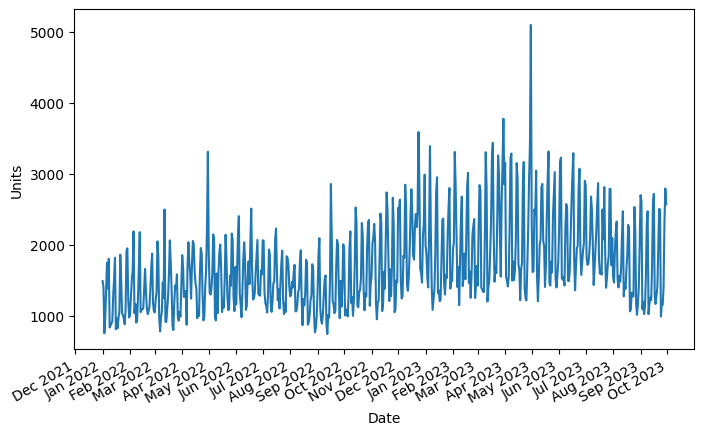

In [38]:
# Look for outliers in demand per day, by aggregating all units sold across all stores sorted per date
daily_sales = sales_df.groupby('Date')['Units'].sum()
print("In total dates: ", daily_sales.shape)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(daily_sales)
ax.set_xlabel("Date")
ax.set_ylabel("Units")

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()  # rotates nicely

plt.show()

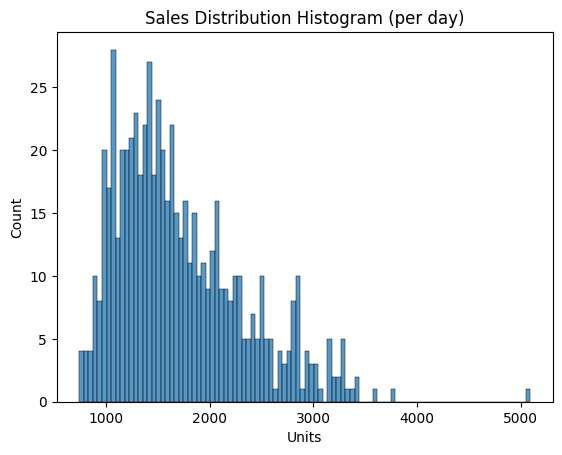

In [39]:
# Plot sales distribution, there is no shop with zero sales as awnsered in the section before
sns.histplot(daily_sales, bins=100)
plt.title('Sales Distribution Histogram (per day)')
plt.show()

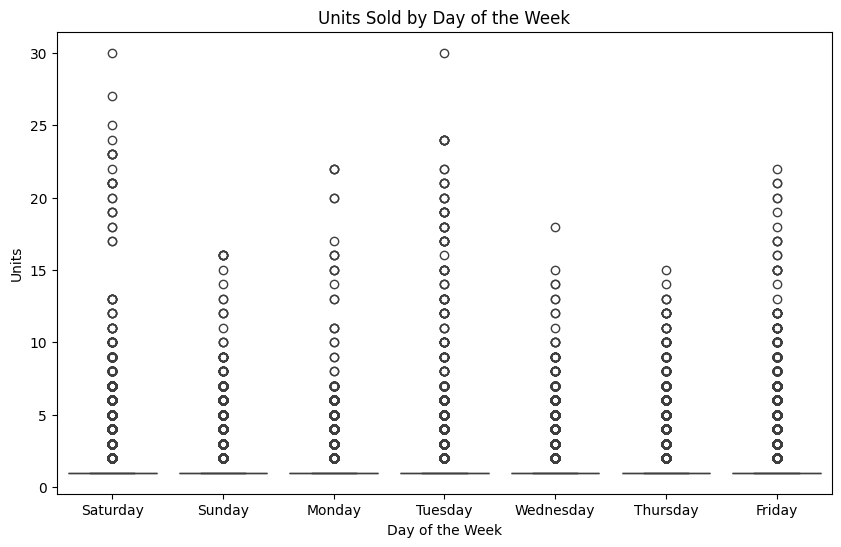

In [40]:
# Boxplot for sales by day of the week
sales_df['DayOfWeek'] = sales_df['Date'].dt.day_name()

plt.figure(figsize=(10,6))
sns.boxplot(x='DayOfWeek', y='Units', data=sales_df)
plt.title('Units Sold by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Units')
plt.show()

## Data Prept Delete rows from train data for closed stores
2.3.3 Data Quality Report

In [41]:
# ---------------------------------------------------
# Data Prep: remove "closed store" rows (Mexican toy store data)
# Interpretation for this dataset:
# - A store is considered "closed" BEFORE its Store_Open_Date.
# - Those rows are not valid sales observations, so we remove them.
# We also remove rows with non-positive Units.
# ---------------------------------------------------

# Standardize column names (safety)
sales_df.columns   = [c.strip() for c in sales_df.columns]
stores_df.columns  = [c.strip() for c in stores_df.columns]
products_df.columns= [c.strip() for c in products_df.columns]
inventory_df.columns=[c.strip() for c in inventory_df.columns]
calendar_df.columns=[c.strip() for c in calendar_df.columns]

# Parse dates
sales_df["Date"] = pd.to_datetime(sales_df["Date"], errors="coerce")
stores_df["Store_Open_Date"] = pd.to_datetime(stores_df["Store_Open_Date"], errors="coerce")
calendar_df["Date"] = pd.to_datetime(calendar_df["Date"], errors="coerce")

# Coerce numeric IDs / Units
for col in ["Sale_ID","Store_ID","Product_ID","Units"]:
    if col in sales_df.columns:
        sales_df[col] = pd.to_numeric(sales_df[col], errors="coerce")

print("Sales shape BEFORE cleaning:", sales_df.shape)

# Attach store open date so we can filter invalid rows
sales_with_open = sales_df.merge(
    stores_df[["Store_ID", "Store_Open_Date"]],
    on="Store_ID",
    how="left",
    validate="many_to_one"
)

# Flag invalid rows: before open date OR missing store open date OR missing sales date
invalid_date_rows = (
    sales_with_open["Date"].isna() |
    sales_with_open["Store_Open_Date"].isna() |
    (sales_with_open["Date"] < sales_with_open["Store_Open_Date"])
)

# Basic quality filters
valid_units = sales_with_open["Units"].fillna(0) > 0

sales_clean = sales_with_open.loc[~invalid_date_rows & valid_units].copy()

print("Sales shape AFTER cleaning:", sales_clean.shape)
print("Rows removed:", len(sales_with_open) - len(sales_clean))

sales_clean.head()


Sales shape BEFORE cleaning: (829262, 6)
Sales shape AFTER cleaning: (829262, 7)
Rows removed: 0


,Sale_ID,Date,Store_ID,Product_ID,Units,DayOfWeek,Store_Open_Date
0,1,2022-01-01,24,4,1,Saturday,2010-07-31
1,2,2022-01-01,28,1,1,Saturday,2011-04-01
2,3,2022-01-01,6,8,1,Saturday,2003-12-13
3,4,2022-01-01,48,7,1,Saturday,2016-03-23
4,5,2022-01-01,44,18,1,Saturday,2014-12-27


## 2.4 First Data Exploration

In [4]:
# ---------------------------------------------------
# 2.4 First Data Exploration (quick look)
# ---------------------------------------------------

print("=== TABLE SHAPES ===")
print("calendar_df :", calendar_df.shape)
print("sales_df    :", sales_df.shape, "(raw)")
print("sales_clean :", sales_clean.shape, "(cleaned)")
print("stores_df   :", stores_df.shape)
print("products_df :", products_df.shape)
print("inventory_df:", inventory_df.shape)

print("\n=== SALES SAMPLE ===")
display(sales_clean.head())

print("\n=== MISSING VALUES (top) ===")
for name, df in [("sales_clean", sales_clean), ("stores_df", stores_df), ("products_df", products_df), ("inventory_df", inventory_df)]:
    miss = df.isna().sum().sort_values(ascending=False)
    print(f"\n{name}:")
    display(miss[miss > 0].head(15))

print("\n=== BASIC SALES STATS ===")
display(sales_clean[["Units"]].describe())

# Top stores / products by units
top_stores = sales_clean.groupby("Store_ID")["Units"].sum().sort_values(ascending=False).head(10)
top_products = sales_clean.groupby("Product_ID")["Units"].sum().sort_values(ascending=False).head(10)

print("\nTop 10 Stores by Units:")
display(top_stores)

print("\nTop 10 Products by Units:")
display(top_products)


=== TABLE SHAPES ===
calendar_df : (638, 1)
sales_df    : (829262, 5) (raw)
sales_clean : (829262, 6) (cleaned)
stores_df   : (50, 5)
products_df : (35, 5)
inventory_df: (1593, 3)

=== SALES SAMPLE ===


,Sale_ID,Date,Store_ID,Product_ID,Units,Store_Open_Date
0,1,2022-01-01,24,4,1,2010-07-31
1,2,2022-01-01,28,1,1,2011-04-01
2,3,2022-01-01,6,8,1,2003-12-13
3,4,2022-01-01,48,7,1,2016-03-23
4,5,2022-01-01,44,18,1,2014-12-27



=== MISSING VALUES (top) ===

sales_clean:


Series([], dtype: int64)


stores_df:


Series([], dtype: int64)


products_df:


Series([], dtype: int64)


inventory_df:


Series([], dtype: int64)


=== BASIC SALES STATS ===


,Units
count,829262.000000
mean,1.315103
std,0.830701
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,30.000000



Top 10 Stores by Units:


Store_ID
31    42757
9     33479
17    32668
30    31609
7     28318
37    26634
39    25296
14    24740
10    24556
46    24136
Name: Units, dtype: int64


Top 10 Products by Units:


Product_ID
6     104368
25    103128
3      91663
8      84034
19     60598
31     60248
18     59737
1      57958
30     45672
2      39089
Name: Units, dtype: int64

## 2.5 Data Preparation and further Data Exploration
Data Prepl Table Store, Column CompetitionDistance...
Data Prepl Table Store, Column Promo2SinceWeek...
Joining train and store data

In [44]:
# ---------------------------------------------------
# 2.5 Data Preparation and further Data Exploration
# - Clean money columns in products
# - Unify ALL datasets into ONE fact table
# ---------------------------------------------------

import pandas as pd
import numpy as np

# ---------- Helpers ----------
def standardize_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]  # remove hidden spaces
    return df

def money_to_float(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
              .str.replace("$", "", regex=False)
              .str.replace(",", "", regex=False)
              .str.strip()
    )

# ---------- Standardize column names (prevents trailing-space bugs) ----------
sales_clean = standardize_cols(sales_clean)
stores_std  = standardize_cols(stores_df)
products_std = standardize_cols(products_df)
inventory_std = standardize_cols(inventory_df)
calendar_std = standardize_cols(calendar_df)

# ---------- Parse key dates ----------
# sales date
if "Date" in sales_clean.columns:
    sales_clean["Date"] = pd.to_datetime(sales_clean["Date"], errors="coerce")

# store open date
if "Store_Open_Date" in stores_std.columns:
    stores_std["Store_Open_Date"] = pd.to_datetime(stores_std["Store_Open_Date"], errors="coerce")

# calendar date (your calendar is mm/dd/yyyy)
if "Date" in calendar_std.columns:
    calendar_std["Date"] = pd.to_datetime(calendar_std["Date"], errors="coerce", infer_datetime_format=True)

# ---------- Clean money columns ----------
products_clean = products_std.copy()
for col in ["Product_Cost", "Product_Price"]:
    if col in products_clean.columns:
        products_clean[col] = pd.to_numeric(money_to_float(products_clean[col]), errors="coerce")

# ---------- Coerce inventory numerics ----------
inventory_clean = inventory_std.copy()
for col in ["Store_ID", "Product_ID", "Stock_On_Hand"]:
    if col in inventory_clean.columns:
        inventory_clean[col] = pd.to_numeric(inventory_clean[col], errors="coerce")

# ---------- UNIFY into one fact table ----------
fact_sales = (
    sales_clean
      .merge(stores_std, on="Store_ID", how="left", validate="many_to_one", suffixes=("", "_store"))
      .merge(products_clean, on="Product_ID", how="left", validate="many_to_one", suffixes=("", "_prod"))
      .merge(inventory_clean, on=["Store_ID","Product_ID"], how="left", validate="many_to_one", suffixes=("", "_inv"))
      .merge(calendar_std, on="Date", how="left", validate="many_to_one", suffixes=("", "_cal"))
)

# ---------- Safety: find store open date column after merge ----------
store_open_candidates = [c for c in fact_sales.columns if c.lower().replace(" ", "") in {
    "store_open_date", "store_open_date_store"
}]
if len(store_open_candidates) == 0:
    print("Available columns that contain 'Open' or 'Date':")
    print([c for c in fact_sales.columns if ("Open" in c) or ("Date" in c)])
    raise KeyError("Store_Open_Date not found in fact_sales after merges. Check store column naming.")
else:
    store_open_col = store_open_candidates[0]

# ---------- Derived fields ----------
# Revenue (if price missing, revenue becomes NaN)
if "Units" in fact_sales.columns and "Product_Price" in fact_sales.columns:
    fact_sales["Revenue"] = fact_sales["Units"] * fact_sales["Product_Price"]

# Store age in days (ensure both are datetime)
fact_sales["Date"] = pd.to_datetime(fact_sales["Date"], errors="coerce")
fact_sales[store_open_col] = pd.to_datetime(fact_sales[store_open_col], errors="coerce")

fact_sales["StoreAgeDays"] = (fact_sales["Date"] - fact_sales[store_open_col]).dt.days

print("Unified fact table shape:", fact_sales.shape)
display(fact_sales.head())
print("\nStore open date column used:", store_open_col)


C:\Users\reser\AppData\Local\Temp\ipykernel_11336\3650623840.py:42: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  calendar_std["Date"] = pd.to_datetime(calendar_std["Date"], errors="coerce", infer_datetime_format=True)


Unified fact table shape: (829262, 18)


,Sale_ID,Date,Store_ID,Product_ID,Units,DayOfWeek,Store_Open_Date,Store_Name,Store_City,Store_Location,Store_Open_Date_store,Product_Name,Product_Category,Product_Cost,Product_Price,Stock_On_Hand,Revenue,StoreAgeDays
0,1,2022-01-01,24,4,1,Saturday,2010-07-31,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,Chutes & Ladders,Games,9.99,12.99,1.0,12.99,4172
1,2,2022-01-01,28,1,1,Saturday,2011-04-01,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01,Action Figure,Toys,9.99,15.99,6.0,15.99,3928
2,3,2022-01-01,6,8,1,Saturday,2003-12-13,Maven Toys Mexicali 1,Mexicali,Commercial,2003-12-13,Deck Of Cards,Games,3.99,6.99,50.0,6.99,6594
3,4,2022-01-01,48,7,1,Saturday,2016-03-23,Maven Toys Saltillo 2,Saltillo,Commercial,2016-03-23,Dart Gun,Sports & Outdoors,11.99,15.99,28.0,15.99,2110
4,5,2022-01-01,44,18,1,Saturday,2014-12-27,Maven Toys Puebla 3,Puebla,Residential,2014-12-27,Lego Bricks,Toys,34.99,39.99,117.0,39.99,2562



Store open date column used: Store_Open_Date


## 2.5.1 Distribution

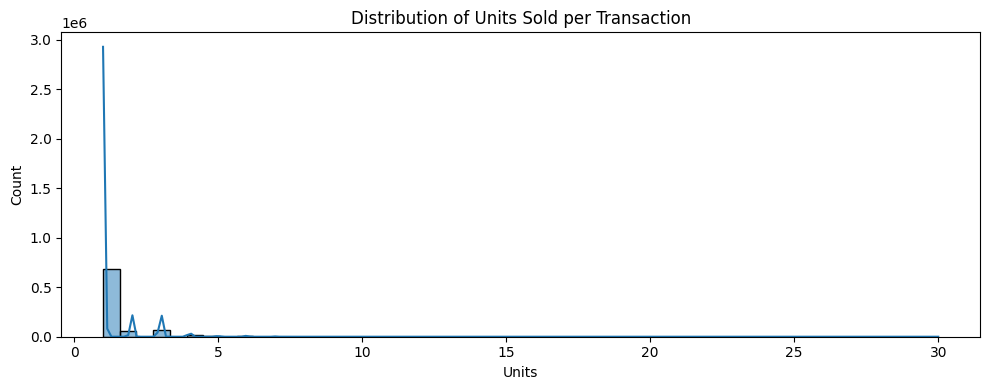

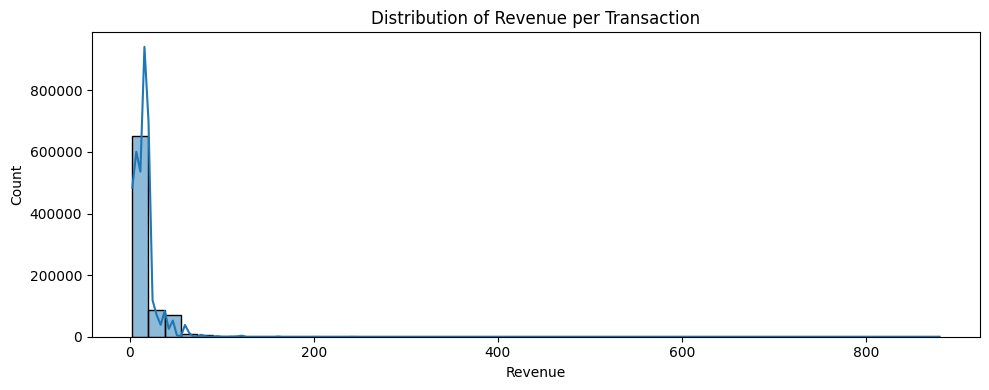

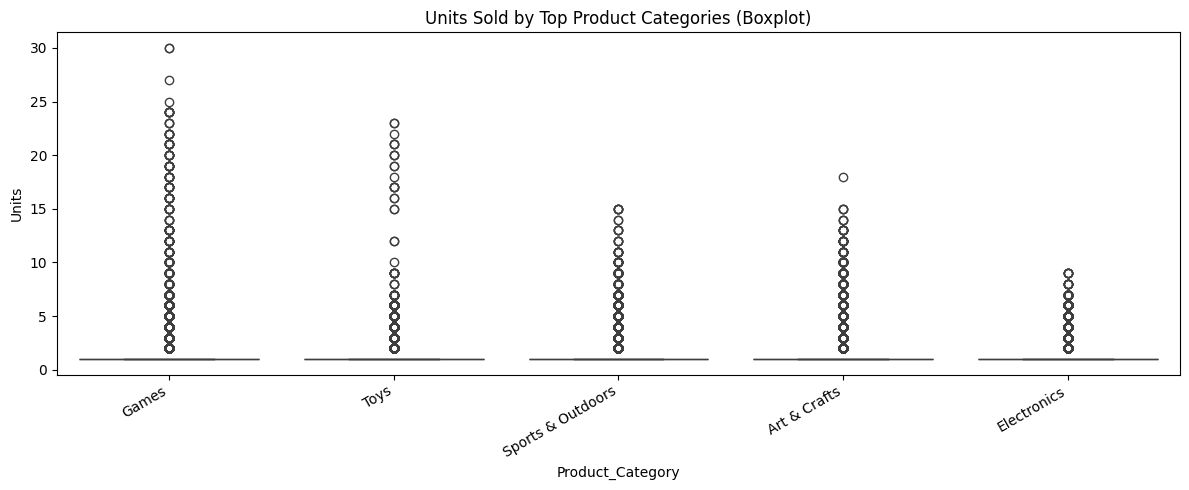

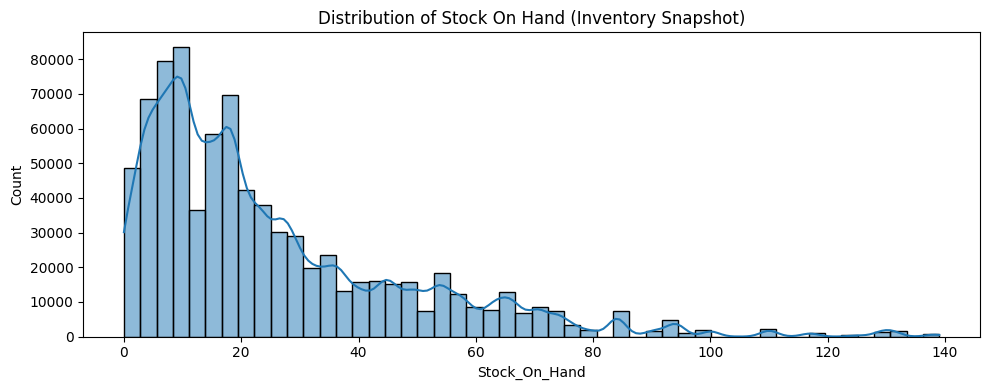

In [6]:
# ---------------------------------------------------
# 2.5.1 Distribution (EDA)
# ---------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt

# Units distribution
plt.figure(figsize=(10,4))
sns.histplot(fact_sales["Units"], bins=50, kde=True)
plt.title("Distribution of Units Sold per Transaction")
plt.xlabel("Units")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Revenue distribution (drop NaNs)
plt.figure(figsize=(10,4))
sns.histplot(fact_sales["Revenue"].dropna(), bins=50, kde=True)
plt.title("Distribution of Revenue per Transaction")
plt.xlabel("Revenue")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Boxplot: Units by Product Category (top 10 categories by volume)
top_cats = (
    fact_sales.groupby("Product_Category")["Units"].sum()
    .sort_values(ascending=False).head(10).index
)
plt.figure(figsize=(12,5))
sns.boxplot(data=fact_sales[fact_sales["Product_Category"].isin(top_cats)],
            x="Product_Category", y="Units")
plt.title("Units Sold by Top Product Categories (Boxplot)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Stock snapshot distribution
if "Stock_On_Hand" in fact_sales.columns:
    plt.figure(figsize=(10,4))
    sns.histplot(fact_sales["Stock_On_Hand"].dropna(), bins=50, kde=True)
    plt.title("Distribution of Stock On Hand (Inventory Snapshot)")
    plt.xlabel("Stock_On_Hand")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


## 2.5.2 Correlations

Numeric columns used for correlation: ['Units', 'Product_Cost', 'Product_Price', 'Stock_On_Hand', 'Revenue', 'StoreAgeDays']


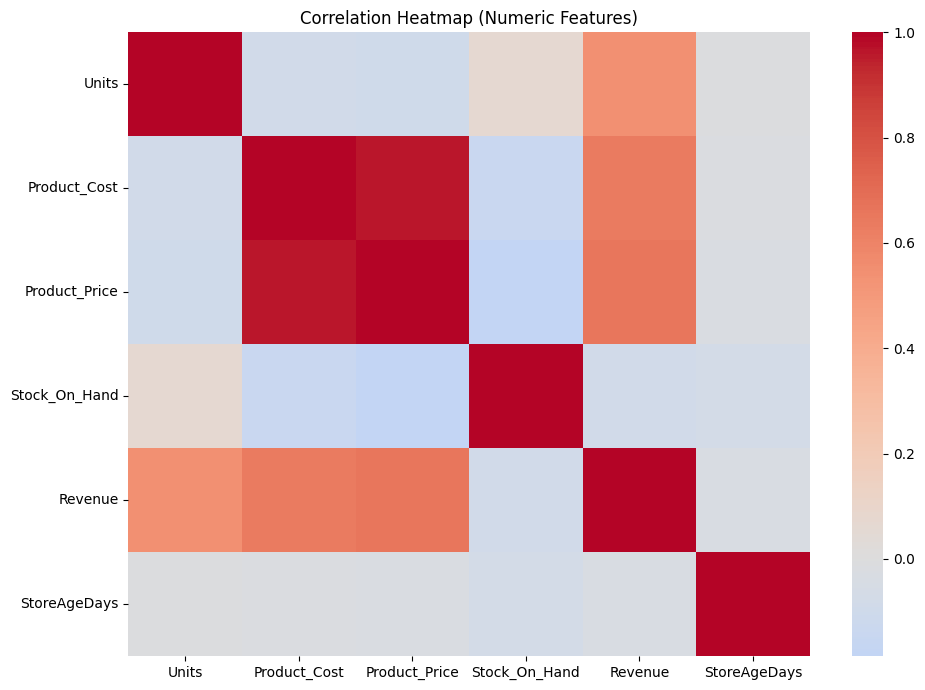


Top correlations with Units:


Units            1.000000
Revenue          0.544936
Stock_On_Hand    0.069369
StoreAgeDays    -0.012018
Product_Cost    -0.083454
Product_Price   -0.096340
Name: Units, dtype: float64


Top correlations with Revenue:


Revenue          1.000000
Product_Price    0.658062
Product_Cost     0.635769
Units            0.544936
StoreAgeDays    -0.027957
Stock_On_Hand   -0.083564
Name: Revenue, dtype: float64

In [47]:
# ---------------------------------------------------
# 2.4.2 Correlations (numerical fields only)
# ---------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = fact_sales.select_dtypes(include=["int64","float64"]).columns.tolist()

# Remove identifier-like columns from correlation (optional but cleaner)
id_like = {"Sale_ID", "Store_ID", "Product_ID"}
num_cols = [c for c in num_cols if c not in id_like]

print("Numeric columns used for correlation:", num_cols)

corr = fact_sales[num_cols].corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

# Strongest correlations with Units / Revenue (if present)
if "Units" in corr.columns:
    print("\nTop correlations with Units:")
    display(corr["Units"].sort_values(ascending=False).head(10))

if "Revenue" in corr.columns:
    print("\nTop correlations with Revenue:")
    display(corr["Revenue"].sort_values(ascending=False).head(10))


## 2.5.3 Time-Series Analysis

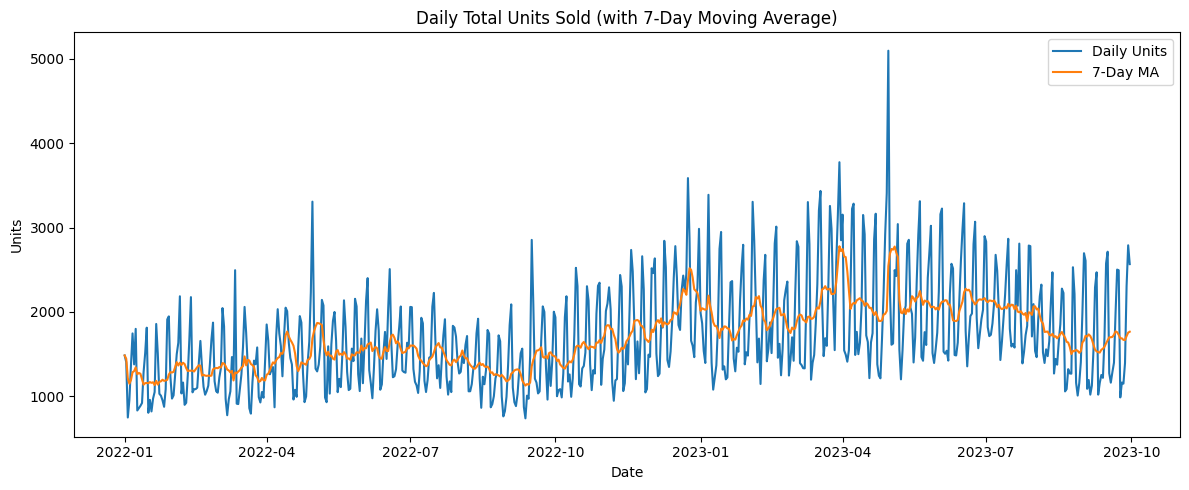

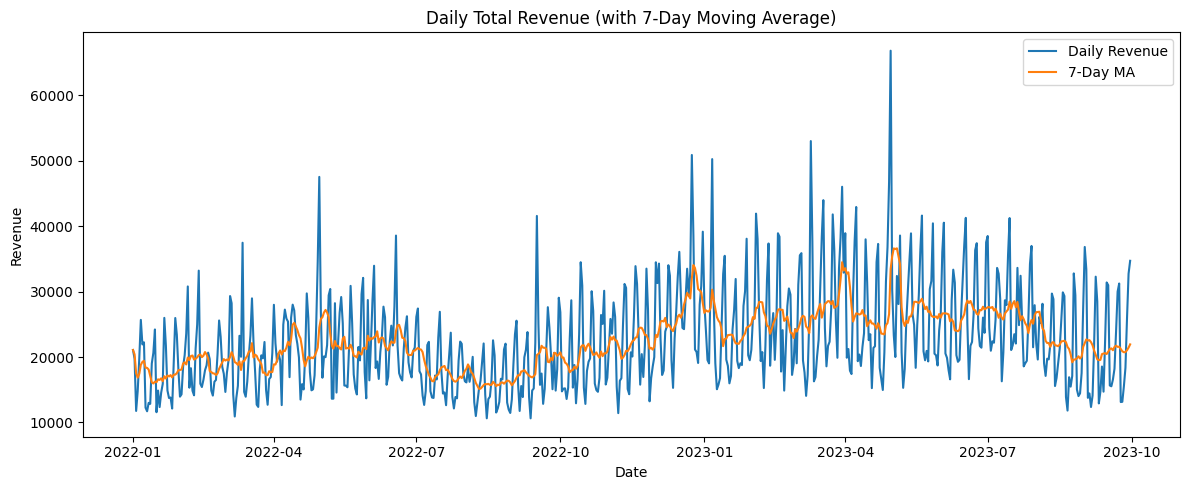

,Date,Units,Units_7D_MA
0,2022-01-01,1485,1485.000000
1,2022-01-02,1406,1445.500000
2,2022-01-03,750,1213.666667
3,2022-01-04,960,1150.250000
4,2022-01-05,1370,1194.200000


In [49]:
# ---------------------------------------------------
# 2.4.3 Time-Series Analysis (with Moving Average)
# What we want to learn (like typical time-series EDA from class):
# - Trend over time (is demand growing or falling?)
# - Seasonality (repeating patterns by week/month)
# - Smoothing with Moving Averages (MA) to reduce noise and reveal trend
# ---------------------------------------------------

import matplotlib.pyplot as plt

daily_units = (
    fact_sales.groupby("Date", as_index=False)["Units"].sum()
    .sort_values("Date")
)

# 7-day moving average is common for smoothing daily series
daily_units["Units_7D_MA"] = daily_units["Units"].rolling(window=7, min_periods=1).mean()

plt.figure(figsize=(12,5))
plt.plot(daily_units["Date"], daily_units["Units"], label="Daily Units")
plt.plot(daily_units["Date"], daily_units["Units_7D_MA"], label="7-Day MA")
plt.title("Daily Total Units Sold (with 7-Day Moving Average)")
plt.xlabel("Date")
plt.ylabel("Units")
plt.legend()
plt.tight_layout()
plt.show()

# Optional: Revenue time series
if fact_sales["Revenue"].notna().any():
    daily_rev = (
        fact_sales.groupby("Date", as_index=False)["Revenue"].sum()
        .sort_values("Date")
    )
    daily_rev["Revenue_7D_MA"] = daily_rev["Revenue"].rolling(window=7, min_periods=1).mean()

    plt.figure(figsize=(12,5))
    plt.plot(daily_rev["Date"], daily_rev["Revenue"], label="Daily Revenue")
    plt.plot(daily_rev["Date"], daily_rev["Revenue_7D_MA"], label="7-Day MA")
    plt.title("Daily Total Revenue (with 7-Day Moving Average)")
    plt.xlabel("Date")
    plt.ylabel("Revenue")
    plt.legend()
    plt.tight_layout()
    plt.show()

display(daily_units.head())


## 2.6 Data Exploration Report

In [ ]:
# ---------------------------------------------------
# 2.6 Data Exploration Report (compact summary)
# ---------------------------------------------------

def data_quality_report(df, name="df"):
    print(f"\n=== DATA QUALITY REPORT: {name} ===")
    print("Shape:", df.shape)
    print("\nDtypes:")
    display(df.dtypes.value_counts())
    print("\nMissing values (top 15):")
    miss = df.isna().sum().sort_values(ascending=False)
    display(miss[miss > 0].head(15))
    print("\nDuplicates:", df.duplicated().sum())
    if "Units" in df.columns:
        print("\nUnits checks:")
        print("  Negative Units:", (df["Units"] < 0).sum())
        print("  Zero Units:", (df["Units"] == 0).sum())

data_quality_report(fact_sales, "fact_sales (unified table)")



=== DATA QUALITY REPORT: fact_sales (unified table) ===
Shape: (829262, 18)

Dtypes:


object            6
int64             5
float64           4
datetime64[ns]    3
Name: count, dtype: int64


Missing values (top 15):


Stock_On_Hand    6232
dtype: int64


Duplicates: 0

Units checks:
  Negative Units: 0
  Zero Units: 0


## 3. Data Preparation

In [51]:
# ---------------------------------------------------
# 3. Data Preparation (create modelling dataset)
# We'll predict demand = Units at a store-product-day level.
# ---------------------------------------------------

# Aggregate to a consistent daily grain: Store_ID x Product_ID x Date
df_model = (
    fact_sales
    .groupby(["Date", "Store_ID", "Product_ID"], as_index=False)
    .agg({
        "Units": "sum",
        "Revenue": "sum",
        "Stock_On_Hand": "mean",
        "Product_Price": "mean",
        "Product_Cost": "mean",
        "StoreAgeDays": "mean",
        "Store_City": "first",
        "Store_Location": "first",
        "Product_Category": "first",
        "Store_Name": "first",
        "Product_Name": "first",
    })
)

# Date features (classic time-series feature engineering)
df_model["Year"] = df_model["Date"].dt.year
df_model["Month"] = df_model["Date"].dt.month
df_model["Day"] = df_model["Date"].dt.day
df_model["DayOfWeek"] = df_model["Date"].dt.dayofweek
df_model["WeekOfYear"] = df_model["Date"].dt.isocalendar().week.astype(int)

print("Model dataset shape:", df_model.shape)
display(df_model.head())


Model dataset shape: (88291, 19)


,Date,Store_ID,Product_ID,Units,Revenue,Stock_On_Hand,Product_Price,Product_Cost,StoreAgeDays,Store_City,Store_Location,Product_Category,Store_Name,Product_Name,Year,Month,Day,DayOfWeek,WeekOfYear
0,2022-01-01,1,21,35,349.65,21.0,9.99,6.99,10697.0,Guadalajara,Residential,Sports & Outdoors,Maven Toys Guadalajara 1,Mini Ping Pong Set,2022,1,1,5,52
1,2022-01-01,1,31,9,80.91,7.0,8.99,7.99,10697.0,Guadalajara,Residential,Sports & Outdoors,Maven Toys Guadalajara 1,Splash Balls,2022,1,1,5,52
2,2022-01-01,1,34,4,103.96,0.0,25.99,20.99,10697.0,Guadalajara,Residential,Electronics,Maven Toys Guadalajara 1,Toy Robot,2022,1,1,5,52
3,2022-01-01,2,18,5,199.95,38.0,39.99,34.99,9746.0,Monterrey,Residential,Toys,Maven Toys Monterrey 1,Lego Bricks,2022,1,1,5,52
4,2022-01-01,3,8,6,41.94,44.0,6.99,3.99,8041.0,Guadalajara,Commercial,Games,Maven Toys Guadalajara 2,Deck Of Cards,2022,1,1,5,52


## Dataset Description

In [52]:
# ---------------------------------------------------
# Dataset Description (quick schema overview)
# ---------------------------------------------------
def describe_table(df, name):
    print(f"\n{name}  |  shape={df.shape}")
    display(df.head(3))
    print("Columns:", list(df.columns))

describe_table(sales_df, "sales_df (raw)")
describe_table(sales_clean, "sales_clean (cleaned)")
describe_table(stores_df, "stores_df")
describe_table(products_df, "products_df")
describe_table(inventory_df, "inventory_df")
describe_table(fact_sales, "fact_sales (unified)")



sales_df (raw)  |  shape=(829262, 5)


,Sale_ID,Date,Store_ID,Product_ID,Units
0,1,2022-01-01,24,4,1
1,2,2022-01-01,28,1,1
2,3,2022-01-01,6,8,1


Columns: ['Sale_ID', 'Date', 'Store_ID', 'Product_ID', 'Units']

sales_clean (cleaned)  |  shape=(829262, 7)


,Sale_ID,Date,Store_ID,Product_ID,Units,DayOfWeek,Store_Open_Date
0,1,2022-01-01,24,4,1,Saturday,2010-07-31
1,2,2022-01-01,28,1,1,Saturday,2011-04-01
2,3,2022-01-01,6,8,1,Saturday,2003-12-13


Columns: ['Sale_ID', 'Date', 'Store_ID', 'Product_ID', 'Units', 'DayOfWeek', 'Store_Open_Date']

stores_df  |  shape=(50, 5)


,Store_ID,Store_Name,Store_City,Store_Location,Store_Open_Date
0,1,Maven Toys Guadalajara 1,Guadalajara,Residential,1992-09-18
1,2,Maven Toys Monterrey 1,Monterrey,Residential,1995-04-27
2,3,Maven Toys Guadalajara 2,Guadalajara,Commercial,1999-12-27


Columns: ['Store_ID', 'Store_Name', 'Store_City', 'Store_Location', 'Store_Open_Date']

products_df  |  shape=(35, 5)


,Product_ID,Product_Name,Product_Category,Product_Cost,Product_Price
0,1,Action Figure,Toys,$9.99,$15.99
1,2,Animal Figures,Toys,$9.99,$12.99
2,3,Barrel O' Slime,Art & Crafts,$1.99,$3.99


Columns: ['Product_ID', 'Product_Name', 'Product_Category', 'Product_Cost', 'Product_Price']

inventory_df  |  shape=(1593, 3)


,Store_ID,Product_ID,Stock_On_Hand
0,1,1,27
1,1,2,0
2,1,3,32


Columns: ['Store_ID', 'Product_ID', 'Stock_On_Hand']

fact_sales (unified)  |  shape=(829262, 18)


,Sale_ID,Date,Store_ID,Product_ID,Units,DayOfWeek,Store_Open_Date,Store_Name,Store_City,Store_Location,Store_Open_Date_store,Product_Name,Product_Category,Product_Cost,Product_Price,Stock_On_Hand,Revenue,StoreAgeDays
0,1,2022-01-01,24,4,1,Saturday,2010-07-31,Maven Toys Aguascalientes 1,Aguascalientes,Downtown,2010-07-31,Chutes & Ladders,Games,9.99,12.99,1.0,12.99,4172
1,2,2022-01-01,28,1,1,Saturday,2011-04-01,Maven Toys Puebla 2,Puebla,Downtown,2011-04-01,Action Figure,Toys,9.99,15.99,6.0,15.99,3928
2,3,2022-01-01,6,8,1,Saturday,2003-12-13,Maven Toys Mexicali 1,Mexicali,Commercial,2003-12-13,Deck Of Cards,Games,3.99,6.99,50.0,6.99,6594


Columns: ['Sale_ID', 'Date', 'Store_ID', 'Product_ID', 'Units', 'DayOfWeek', 'Store_Open_Date', 'Store_Name', 'Store_City', 'Store_Location', 'Store_Open_Date_store', 'Product_Name', 'Product_Category', 'Product_Cost', 'Product_Price', 'Stock_On_Hand', 'Revenue', 'StoreAgeDays']


## 3.1 Select Data

In [54]:
# ---------------------------------------------------
# 3.1 Select Data
# Target: Units (demand)
# Features: store/product attributes, inventory snapshot, time features
# ---------------------------------------------------

target_col = "Units"

feature_cols = [
    "Store_ID","Product_ID",
    "Stock_On_Hand","Product_Price","Product_Cost",
    "StoreAgeDays",
    "Year","Month","Day","DayOfWeek","WeekOfYear",
    "Store_City","Store_Location","Product_Category"
]

# Keep only columns that exist
feature_cols = [c for c in feature_cols if c in df_model.columns]

X_raw = df_model[feature_cols].copy()
y = df_model[target_col].copy()

print("Selected features:", feature_cols)
print("X_raw shape:", X_raw.shape, "| y shape:", y.shape)
display(X_raw.head())


Selected features: ['Store_ID', 'Product_ID', 'Stock_On_Hand', 'Product_Price', 'Product_Cost', 'StoreAgeDays', 'Year', 'Month', 'Day', 'DayOfWeek', 'WeekOfYear', 'Store_City', 'Store_Location', 'Product_Category']
X_raw shape: (88291, 14) | y shape: (88291,)


,Store_ID,Product_ID,Stock_On_Hand,Product_Price,Product_Cost,StoreAgeDays,Year,Month,Day,DayOfWeek,WeekOfYear,Store_City,Store_Location,Product_Category
0,1,21,21.0,9.99,6.99,10697.0,2022,1,1,5,52,Guadalajara,Residential,Sports & Outdoors
1,1,31,7.0,8.99,7.99,10697.0,2022,1,1,5,52,Guadalajara,Residential,Sports & Outdoors
2,1,34,0.0,25.99,20.99,10697.0,2022,1,1,5,52,Guadalajara,Residential,Electronics
3,2,18,38.0,39.99,34.99,9746.0,2022,1,1,5,52,Monterrey,Residential,Toys
4,3,8,44.0,6.99,3.99,8041.0,2022,1,1,5,52,Guadalajara,Commercial,Games


## 3.2 Clean Data

In [55]:
# ---------------------------------------------------
# 3.2 Clean Data (handle missing values)
# ---------------------------------------------------

df_clean = pd.concat([X_raw, y.rename("Units")], axis=1)

# Basic missing-value handling
# - numeric: median
# - categorical: 'Unknown'
num_cols = df_clean.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()

# Remove target from lists if present
num_cols = [c for c in num_cols if c != "Units"]

for c in num_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())

for c in cat_cols:
    df_clean[c] = df_clean[c].fillna("Unknown")

# (Optional) clip extreme outliers of Units to reduce training instability
q_low, q_high = df_clean["Units"].quantile([0.01, 0.99])
df_clean["Units"] = df_clean["Units"].clip(lower=q_low, upper=q_high)

print("Missing values AFTER cleaning (top):")
display(df_clean.isna().sum().sort_values(ascending=False).head(10))

display(df_clean.head())


Missing values AFTER cleaning (top):


Store_ID         0
Product_ID       0
Stock_On_Hand    0
Product_Price    0
Product_Cost     0
StoreAgeDays     0
Year             0
Month            0
Day              0
DayOfWeek        0
dtype: int64

,Store_ID,Product_ID,Stock_On_Hand,Product_Price,Product_Cost,StoreAgeDays,Year,Month,Day,DayOfWeek,WeekOfYear,Store_City,Store_Location,Product_Category,Units
0,1,21,21.0,9.99,6.99,10697.0,2022,1,1,5,52,Guadalajara,Residential,Sports & Outdoors,35
1,1,31,7.0,8.99,7.99,10697.0,2022,1,1,5,52,Guadalajara,Residential,Sports & Outdoors,9
2,1,34,0.0,25.99,20.99,10697.0,2022,1,1,5,52,Guadalajara,Residential,Electronics,4
3,2,18,38.0,39.99,34.99,9746.0,2022,1,1,5,52,Monterrey,Residential,Toys,5
4,3,8,44.0,6.99,3.99,8041.0,2022,1,1,5,52,Guadalajara,Commercial,Games,6


## 3.3 Construct Data

In [56]:
# ---------------------------------------------------
# 3.3 Construct Data (feature engineering)
# - Rolling mean features help capture short-term demand patterns (time-series concept)
# ---------------------------------------------------

df_feat = df_clean.copy()

# Sort for rolling features
df_feat = df_feat.sort_values(["Store_ID","Product_ID","Year","Month","Day"])

# Re-attach Date for rolling computation (from df_model)
df_feat["Date"] = df_model["Date"].values
df_feat = df_feat.sort_values(["Store_ID","Product_ID","Date"])

# Rolling 7-day mean of Units per store-product (lagged to avoid leakage)
df_feat["Units_7D_MA_LAG1"] = (
    df_feat.groupby(["Store_ID","Product_ID"])["Units"]
    .shift(1)
    .rolling(window=7, min_periods=1)
    .mean()
)

# Fill any remaining NA from the first observation
df_feat["Units_7D_MA_LAG1"] = df_feat["Units_7D_MA_LAG1"].fillna(df_feat["Units_7D_MA_LAG1"].median())

print("Feature set shape after construction:", df_feat.shape)
display(df_feat[["Store_ID","Product_ID","Date","Units","Units_7D_MA_LAG1"]].head(10))


Feature set shape after construction: (88291, 17)


,Store_ID,Product_ID,Date,Units,Units_7D_MA_LAG1
118,1,1,2022-01-01,9,11.285714
294,1,1,2022-01-01,6,9.000000
755,1,1,2022-01-01,3,7.500000
1427,1,1,2022-01-01,3,6.000000
1635,1,1,2022-01-01,3,5.250000
1976,1,1,2022-01-01,14,4.800000
2693,1,1,2022-01-01,9,6.333333
2829,1,1,2022-01-01,16,6.714286
4341,1,1,2022-01-01,14,7.714286
4595,1,1,2022-01-01,6,8.857143


## 3.4 Integrate Data

In [57]:
# ---------------------------------------------------
# 3.4 Integrate Data
# At this point, df_feat is already integrated because it came from fact_sales (the unified table).
# We'll just confirm the join logic and that key columns exist.
# ---------------------------------------------------

required_cols = ["Store_ID","Product_ID","Date","Units"]
missing_required = [c for c in required_cols if c not in df_feat.columns]
print("Missing required columns:", missing_required)

print("\nUnified source table:", "fact_sales")
print("Modelling table:", "df_feat")
print("fact_sales shape:", fact_sales.shape)
print("df_feat shape:", df_feat.shape)


Missing required columns: []

Unified source table: fact_sales
Modelling table: df_feat
fact_sales shape: (829262, 18)
df_feat shape: (88291, 17)


## 3.5 Format Data

In [58]:
# ---------------------------------------------------
# 3.5 Format Data
# - One-hot encode categorical features
# - Time-based train/validation split (more realistic for forecasting)
# ---------------------------------------------------
from sklearn.model_selection import train_test_split

# Separate target
y_final = df_feat["Units"].copy()

# Features: drop target + Date
X = df_feat.drop(columns=["Units", "Date"])

# One-hot encode categoricals
X_encoded = pd.get_dummies(X, drop_first=True)

# Time-based split: last 20% of dates as validation
df_feat_sorted = df_feat.sort_values("Date").reset_index(drop=True)
cutoff_idx = int(len(df_feat_sorted) * 0.8)

train_idx = df_feat_sorted.index[:cutoff_idx]
val_idx   = df_feat_sorted.index[cutoff_idx:]

X_encoded_sorted = X_encoded.loc[df_feat_sorted.index]
y_sorted = y_final.loc[df_feat_sorted.index]

X_train = X_encoded_sorted.loc[train_idx]
y_train = y_sorted.loc[train_idx]
X_val   = X_encoded_sorted.loc[val_idx]
y_val   = y_sorted.loc[val_idx]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)

display(X_train.head())

# ---------------------------------------------------
# Save train and validation sets to CSV
# ---------------------------------------------------

# Combine X and y for train
train_df = pd.concat([X_train, y_train.rename("Units")], axis=1)

# Combine X and y for validation
val_df = pd.concat([X_val, y_val.rename("Units")], axis=1)

# Save to CSV
train_df.to_csv("train_data.csv", index=False)
val_df.to_csv("validation_data.csv", index=False)

print("Train and validation datasets saved successfully.")


X_train: (70632, 47) y_train: (70632,)
X_val  : (17659, 47) y_val  : (17659,)


,Store_ID,Product_ID,Stock_On_Hand,Product_Price,Product_Cost,StoreAgeDays,Year,Month,Day,DayOfWeek,...,Store_City_Villahermosa,Store_City_Xalapa,Store_City_Zacatecas,Store_Location_Commercial,Store_Location_Downtown,Store_Location_Residential,Product_Category_Electronics,Product_Category_Games,Product_Category_Sports & Outdoors,Product_Category_Toys
0,1,21,21.0,9.99,6.99,10697.0,2022,1,1,5,...,False,False,False,False,False,True,False,False,True,False
1,1,31,7.0,8.99,7.99,10697.0,2022,1,1,5,...,False,False,False,False,False,True,False,False,True,False
2,1,34,0.0,25.99,20.99,10697.0,2022,1,1,5,...,False,False,False,False,False,True,True,False,False,False
3,2,18,38.0,39.99,34.99,9746.0,2022,1,1,5,...,False,False,False,False,False,True,False,False,False,True
4,3,8,44.0,6.99,3.99,8041.0,2022,1,1,5,...,False,False,False,True,False,False,False,True,False,False


Train and validation datasets saved successfully.


## 4. Modelling

In [59]:
# ---------------------------------------------------
# 4. Modelling (focus: XGBoost for demand forecasting)
# We'll still compare against a simple baseline so the gain is obvious.
# ---------------------------------------------------
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    denom = np.where(y_true == 0, 1, y_true)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

# Baseline: predict average Units from training set
baseline_pred = np.full(shape=len(y_val), fill_value=y_train.mean())
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_val, baseline_pred)))
print("Baseline MAE :", mean_absolute_error(y_val, baseline_pred))
print("Baseline MAPE:", mape(y_val, baseline_pred))

# XGBoost
try:
    from xgboost import XGBRegressor
    xgb_available = True
except Exception as e:
    xgb_available = False
    print("XGBoost not available:", e)

if xgb_available:
    xgb_model = XGBRegressor(
        n_estimators=600,
        max_depth=10,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    xgb_model.fit(X_train, y_train)
    y_val_pred = xgb_model.predict(X_val)

    print("\nXGBoost RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))
    print("XGBoost MAE :", mean_absolute_error(y_val, y_val_pred))
    print("XGBoost MAPE:", mape(y_val, y_val_pred))


Baseline RMSE: 9.517346533399781
Baseline MAE : 6.73808770279021
Baseline MAPE: 114.5004063420105

XGBoost RMSE: 9.917197547187483
XGBoost MAE : 7.302774906158447
XGBoost MAPE: 125.90008229348601


## 4.1 Select Modelling

In [60]:
# ---------------------------------------------------
# 4.1 Select Modelling
# We focus on XGBoost as the main model (tree boosting works well with mixed features).
# ---------------------------------------------------
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

models = {
    "Baseline (Mean)": None,  # handled separately
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
}

if xgb_available:
    models["XGBoost"] = xgb_model

print("Models selected:", list(models.keys()))


Models selected: ['Baseline (Mean)', 'Linear Regression', 'Random Forest', 'XGBoost']


## 4.2 Techniques

In [61]:
# ---------------------------------------------------
# 4.2 Techniques (train + compare)
# ---------------------------------------------------
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

results = []

# Baseline
baseline_pred = np.full(shape=len(y_val), fill_value=y_train.mean())
results.append({
    "Model": "Baseline (Mean)",
    "RMSE": np.sqrt(mean_squared_error(y_val, baseline_pred)),
    "MAE": mean_absolute_error(y_val, baseline_pred),
    "MAPE": mape(y_val, baseline_pred)
})

for name, model in models.items():
    if model is None or name == "Baseline (Mean)":
        continue
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    results.append({
        "Model": name,
        "RMSE": np.sqrt(mean_squared_error(y_val, pred)),
        "MAE": mean_absolute_error(y_val, pred),
        "MAPE": mape(y_val, pred)
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
print("Best model:", best_model_name)


,Model,RMSE,MAE,MAPE
1,Linear Regression,9.438113,6.749469,114.704179
2,Random Forest,9.504421,6.864089,117.004052
0,Baseline (Mean),9.517347,6.738088,114.500406
3,XGBoost,9.917198,7.302775,125.900082


Best model: Linear Regression


## 4.3 Generate Test Design

In [62]:
# ---------------------------------------------------
# 4.3 Generate Test Design (forecast table)
# In this project we don't have a separate external test file,
# so we generate a 'test design' on the validation window.
# ---------------------------------------------------
best_model = None
if best_model_name == "Baseline (Mean)":
    best_model = None
elif best_model_name in models:
    best_model = models[best_model_name]

val_design = df_feat_sorted.loc[val_idx, ["Date","Store_ID","Product_ID"]].copy()
val_design["ActualUnits"] = y_val.values

if best_model is None:
    val_design["PredictedUnits"] = y_train.mean()
else:
    val_design["PredictedUnits"] = best_model.predict(X_val)

val_design["Error"] = val_design["ActualUnits"] - val_design["PredictedUnits"]
display(val_design.head(10))


,Date,Store_ID,Product_ID,ActualUnits,PredictedUnits,Error
70632,2023-06-09,40,17,21,13.038527,7.961473
70633,2023-06-09,40,16,3,14.136438,-11.136438
70634,2023-06-09,40,17,13,13.414217,-0.414217
70635,2023-06-09,40,16,3,11.338271,-8.338271
70636,2023-06-09,40,16,5,13.726722,-8.726722
70637,2023-06-09,40,18,11,13.894518,-2.894518
70638,2023-06-09,40,15,7,10.839552,-3.839552
70639,2023-06-09,40,15,1,11.501210,-10.501210
70640,2023-06-09,40,15,16,11.459856,4.540144
70641,2023-06-09,40,15,5,11.012042,-6.012042


## 4.4 Build Model

In [63]:
# ---------------------------------------------------
# 4.4 Build Model (train final XGBoost on ALL data)
# ---------------------------------------------------
if not xgb_available:
    raise RuntimeError("XGBoost is not available, cannot build final model.")

X_all = X_encoded
y_all = y_final

final_xgb = XGBRegressor(
    n_estimators=800,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

final_xgb.fit(X_all, y_all)
print("Final XGBoost trained on full dataset.")


Final XGBoost trained on full dataset.


## 4.5 Assess Model

Validation RMSE: 9.92
Validation MAE : 7.30
Validation R2  : -0.0870


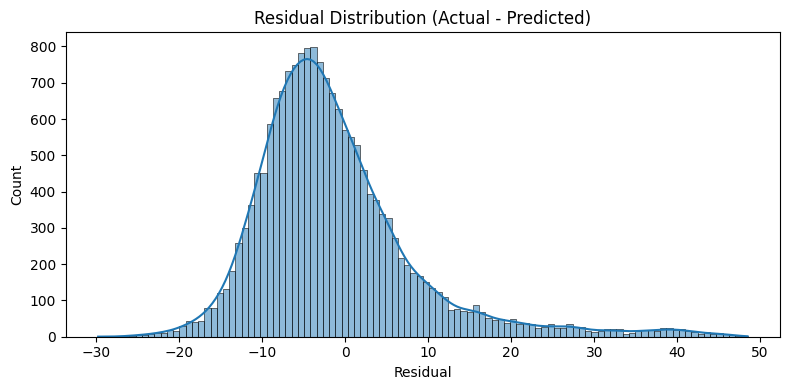

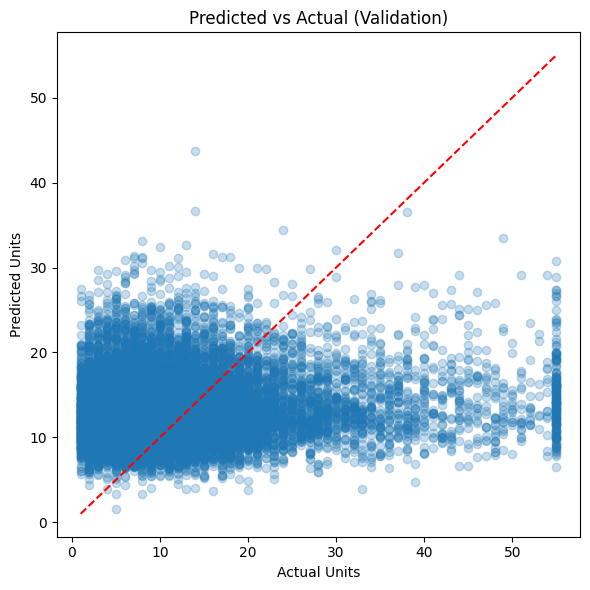

Top 15 important features:


,feature,importance
18,Store_City_Cuidad de Mexico,0.026396
36,Store_City_Tuxtla Gutierrez,0.025548
14,Store_City_Chihuahua,0.025528
35,Store_City_Toluca,0.024829
29,Store_City_Oaxaca,0.024642
31,Store_City_Puebla,0.024376
12,Store_City_Campeche,0.024170
22,Store_City_Guanajuato,0.023652
28,Store_City_Morelia,0.023344
26,Store_City_Mexicali,0.023337


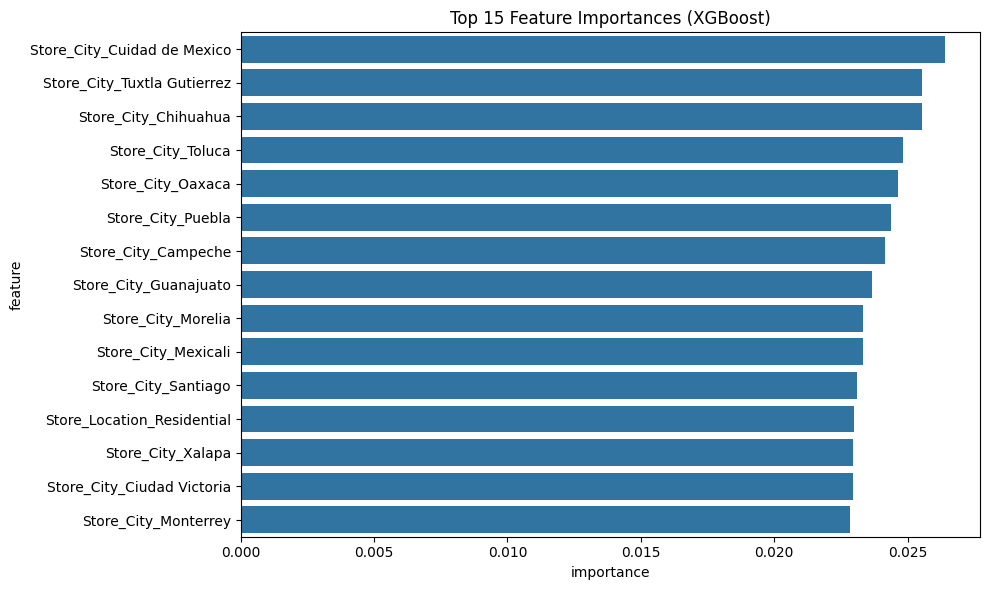

In [64]:
# ---------------------------------------------------
# 4.5 Assess Model (validation plots + feature importance)
# ---------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score

# Re-fit a model on train split for fair validation assessment
assess_model = XGBRegressor(
    n_estimators=600,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)
assess_model.fit(X_train, y_train)
pred = assess_model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, pred))
mae = mean_absolute_error(y_val, pred)
r2 = r2_score(y_val, pred)

print(f"Validation RMSE: {rmse:.2f}")
print(f"Validation MAE : {mae:.2f}")
print(f"Validation R2  : {r2:.4f}")

residuals = y_val.values - pred

plt.figure(figsize=(8,4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution (Actual - Predicted)")
plt.xlabel("Residual")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y_val, pred, alpha=0.25)
min_v = min(y_val.min(), pred.min())
max_v = max(y_val.max(), pred.max())
plt.plot([min_v, max_v],[min_v, max_v], "r--")
plt.title("Predicted vs Actual (Validation)")
plt.xlabel("Actual Units")
plt.ylabel("Predicted Units")
plt.tight_layout()
plt.show()

# Feature importance
importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": assess_model.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 15 important features:")
display(importances.head(15))

plt.figure(figsize=(10,6))
sns.barplot(data=importances.head(15), x="importance", y="feature")
plt.title("Top 15 Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()


## 5. Evaluation

## 5.1 Evaluate Results

## 5.2 Review Process

## 5.3 Determine Next Steps

## 6. Deployment / Finalization

## 6.1 Plan Deployment

## 6.2 Plan Monitoring and Maintenance

## 6.3 Produce Final Report

## 6.4 Review Project